In [17]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from torch.nn.utils.rnn import pad_sequence
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [18]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [19]:

data = pd.read_csv("ner_dataset.csv", encoding="latin1").ffill()
words = list(data["Word"].unique())
tags = list(data["Tag"].unique())

if "ENDPAD" not in words:
    words.append("ENDPAD")

word2idx = {w: i + 1 for i, w in enumerate(words)}
tag2idx = {t: i for i, t in enumerate(tags)}
idx2tag = {i: t for t, i in tag2idx.items()}

In [20]:
data.head(30)

,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,Sentence: 1,of,IN,O
2,Sentence: 1,demonstrators,NNS,O
3,Sentence: 1,have,VBP,O
4,Sentence: 1,marched,VBN,O
5,Sentence: 1,through,IN,O
6,Sentence: 1,London,NNP,B-geo
7,Sentence: 1,to,TO,O
8,Sentence: 1,protest,VB,O
9,Sentence: 1,the,DT,O


Essential info about tagged entities:
```
geo = Geographical Entity
org = Organization
per = Person
gpe = Geopolitical Entity
tim = Time indicator
art = Artifact
eve = Event
nat = Natural Phenomenon
```

In [21]:
print("Unique words in corpus:", data['Word'].nunique())
print("Unique tags in corpus:", data['Tag'].nunique())

Unique words in corpus: 35177
Unique tags in corpus: 17


In [22]:
print("Unique tags are:", tags)

Unique tags are: ['O', 'B-geo', 'B-gpe', 'B-per', 'I-geo', 'B-org', 'I-org', 'B-tim', 'B-art', 'I-art', 'I-per', 'I-gpe', 'I-tim', 'B-nat', 'B-eve', 'I-eve', 'I-nat']


In [23]:

grouped_data = data.groupby("Sentence #", group_keys=False).apply(
    lambda s: [(w, p, t) for w, p, t in zip(s["Word"].values.tolist(),
                                           s["POS"].values.tolist(),
                                           s["Tag"].values.tolist())],
    include_groups=False 
)
sentences = list(grouped_data)

In [24]:
sentences[35]

[('The', 'DT', 'O'),
 ('U.S.', 'NNP', 'B-org'),
 ('Geological', 'NNP', 'I-org'),
 ('Survey', 'NNP', 'I-org'),
 ('gave', 'VBD', 'O'),
 ('a', 'DT', 'O'),
 ('preliminary', 'JJ', 'O'),
 ('estimate', 'NN', 'O'),
 ('of', 'IN', 'O'),
 ('the', 'DT', 'O'),
 ('strength', 'NN', 'O'),
 ('of', 'IN', 'O'),
 ('the', 'DT', 'O'),
 ('Tuesday', 'NNP', 'B-tim'),
 ('morning', 'NN', 'I-tim'),
 ('quake', 'NN', 'O'),
 ('at', 'IN', 'O'),
 ('6.7', 'CD', 'O'),
 ('on', 'IN', 'O'),
 ('the', 'DT', 'O'),
 ('Richter', 'NNP', 'B-geo'),
 ('scale', 'NN', 'O'),
 (',', ',', 'O'),
 ('and', 'CC', 'O'),
 ('said', 'VBD', 'O'),
 ('the', 'DT', 'O'),
 ('epicenter', 'NN', 'O'),
 ('was', 'VBD', 'O'),
 ('close', 'RB', 'O'),
 ('to', 'TO', 'O'),
 ('the', 'DT', 'O'),
 ('island', 'NN', 'O'),
 ('of', 'IN', 'O'),
 ('Nias', 'NNP', 'B-org'),
 ('.', '.', 'O')]

In [27]:
X = [[word2idx[w] for w, p, t in s] for s in sentences]
y = [[tag2idx[t] for w, p, t in s] for s in sentences]

In [28]:
word2idx

{'Thousands': 1,
 'of': 2,
 'demonstrators': 3,
 'have': 4,
 'marched': 5,
 'through': 6,
 'London': 7,
 'to': 8,
 'protest': 9,
 'the': 10,
 'war': 11,
 'in': 12,
 'Iraq': 13,
 'and': 14,
 'demand': 15,
 'withdrawal': 16,
 'British': 17,
 'troops': 18,
 'from': 19,
 'that': 20,
 'country': 21,
 '.': 22,
 'Families': 23,
 'soldiers': 24,
 'killed': 25,
 'conflict': 26,
 'joined': 27,
 'protesters': 28,
 'who': 29,
 'carried': 30,
 'banners': 31,
 'with': 32,
 'such': 33,
 'slogans': 34,
 'as': 35,
 '"': 36,
 'Bush': 37,
 'Number': 38,
 'One': 39,
 'Terrorist': 40,
 'Stop': 41,
 'Bombings': 42,
 'They': 43,
 'Houses': 44,
 'Parliament': 45,
 'a': 46,
 'rally': 47,
 'Hyde': 48,
 'Park': 49,
 'Police': 50,
 'put': 51,
 'number': 52,
 'marchers': 53,
 'at': 54,
 '10,000': 55,
 'while': 56,
 'organizers': 57,
 'claimed': 58,
 'it': 59,
 'was': 60,
 '1,00,000': 61,
 'The': 62,
 'comes': 63,
 'on': 64,
 'eve': 65,
 'annual': 66,
 'conference': 67,
 'Britain': 68,
 "'s": 69,
 'ruling': 70,
 'L

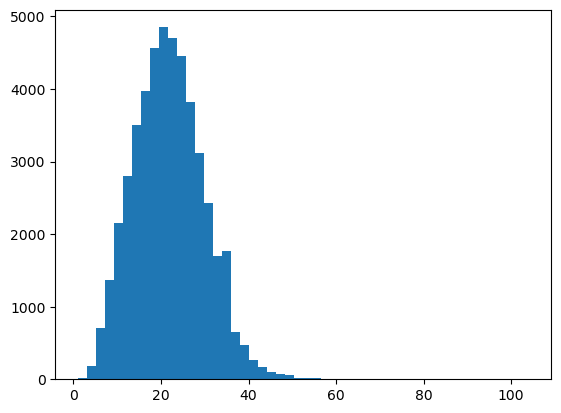

In [29]:
plt.hist([len(s) for s in sentences], bins=50)
plt.show()

In [30]:
max_len = 50
X_pad = pad_sequence([torch.tensor(seq) for seq in X], batch_first=True, padding_value=word2idx["ENDPAD"])
y_pad = pad_sequence([torch.tensor(seq) for seq in y], batch_first=True, padding_value=tag2idx["O"])
X_pad = X_pad[:, :max_len]
y_pad = y_pad[:, :max_len]

In [31]:
X_pad[0]

tensor([    1,     2,     3,     4,     5,     6,     7,     8,     9,    10,
           11,    12,    13,    14,    15,    10,    16,     2,    17,    18,
           19,    20,    21,    22, 35178, 35178, 35178, 35178, 35178, 35178,
        35178, 35178, 35178, 35178, 35178, 35178, 35178, 35178, 35178, 35178,
        35178, 35178, 35178, 35178, 35178, 35178, 35178, 35178, 35178, 35178])

In [32]:
y_pad[0]

tensor([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0])

In [33]:

X_train, X_test, y_train, y_test = train_test_split(X_pad, y_pad, test_size=0.2, random_state=1)

In [34]:
class NERDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "input_ids": self.X[idx],
            "labels": self.y[idx]
        }

train_loader = DataLoader(NERDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(NERDataset(X_test, y_test), batch_size=32)


In [35]:
class BiLSTMTagger(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, tagset_size):
        super(BiLSTMTagger, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.hidden2tag = nn.Linear(hidden_dim * 2, tagset_size)

    def forward(self, input_ids):
        embeds = self.embedding(input_ids)
        lstm_out, _ = self.lstm(embeds)
        tag_space = self.hidden2tag(lstm_out)
        return tag_space

In [36]:
VOCAB_SIZE = len(word2idx)
EMBEDDING_DIM = 128
HIDDEN_DIM = 64
TAGSET_SIZE = len(tag2idx)

model = BiLSTMTagger(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, TAGSET_SIZE).to(device)

loss_fn = nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [37]:
model = BiLSTMTagger(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, TAGSET_SIZE).to(device)
loss_fn = nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [38]:
def train_model(model, train_loader, test_loader, loss_fn, optimizer, epochs=3):
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        
        for batch in train_loader:
            # Depending on your Dataset class, these might be batch['input_ids'] 
            # or directly unpacked. Adjust if needed.
            inputs = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            # Reshape for CrossEntropyLoss: (Batch * Seq_Len, Num_Tags)
            outputs = outputs.view(-1, outputs.shape[-1])
            labels = labels.view(-1)

            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation Phase
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch in test_loader:
                inputs = batch["input_ids"].to(device)
                labels = batch["labels"].to(device)
                outputs = model(inputs)
                
                outputs = outputs.view(-1, outputs.shape[-1])
                labels = labels.view(-1)
                
                loss = loss_fn(outputs, labels)
                total_val_loss += loss.item()
        
        avg_val_loss = total_val_loss / len(test_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    return train_losses, val_losses

In [39]:

max_id = X_train.max() 
print(f"Max ID in data: {max_id}")
print(f"Current VOCAB_SIZE: {VOCAB_SIZE}")



Max ID in data: 35178
Current VOCAB_SIZE: 35178


In [45]:
# Use the actual length of your word mapping
VOCAB_SIZE = len(word2idx) + 1 

# Re-initialize the model with the correct size
model = BiLSTMTagger(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, TAGSET_SIZE).to(device)

# Re-define the optimizer for the NEW model parameters
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Now try running the training function again
train_losses, val_losses = train_model(model, train_loader, test_loader, loss_fn, optimizer, epochs=5)

Epoch 1/5 | Train Loss: 0.1810 | Val Loss: 0.0839
Epoch 2/5 | Train Loss: 0.0658 | Val Loss: 0.0631
Epoch 3/5 | Train Loss: 0.0478 | Val Loss: 0.0575
Epoch 4/5 | Train Loss: 0.0378 | Val Loss: 0.0549
Epoch 5/5 | Train Loss: 0.0310 | Val Loss: 0.0549


Name:KESHAVARTHINI B
Register Number: 212224040158


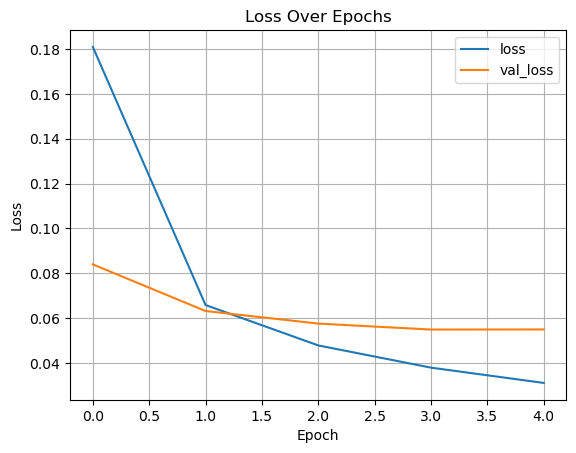

In [46]:
print('Name:KESHAVARTHINI B')
print('Register Number: 212224040158')
history_df = pd.DataFrame({"loss": train_losses, "val_loss": val_losses})
history_df.plot(title="Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [47]:
i = 125
model.eval()
sample = X_test[i].unsqueeze(0).to(device)
output = model(sample)
preds = torch.argmax(output, dim=-1).squeeze().cpu().numpy()
t

print('Name:KESHAVARTHINI B')
print('Register Number: 212224040158    ')
print("{:<15} {:<10} {}\n{}".format("Word", "True", "Pred", "-" * 40))
for w_id, true_tag, pred_tag in zip(X_test[i], y_test[i], preds):
    if w_id.item() != word2idx["ENDPAD"]:
        word = words[w_id.item() - 1]
        true_label = tags[true_tag.item()]
        pred_label = tags[pred_tag]
        print(f"{word:<15} {true_label:<10} {pred_label}")

Name:KESHAVARTHINI B
Register Number: 212224040158    
Word            True       Pred
----------------------------------------
Palestinian     B-gpe      B-gpe
officials       O          O
say             O          O
two             O          O
Palestinians    B-gpe      B-gpe
have            O          O
been            O          O
killed          O          O
in              O          O
an              O          O
accidental      O          O
explosion       O          O
in              O          O
a               O          O
West            B-org      B-org
Bank            I-org      I-org
refugee         O          O
camp            O          O
.               O          O
